# Box Plot

In [1]:
# Import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_beginner_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_US = df[(df['job_title_short']== 'Data Analyst') & (df['job_country']== 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset = 'salary_year_avg')

<Axes: >

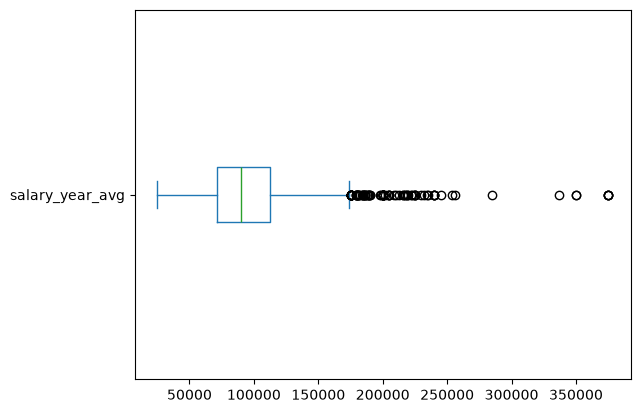

In [ ]:
df_DA_US['salary_year_avg'].plot(kind='box', vert=False)

In [37]:
job_titles = ['Data Analyst', 'Data Engineer', "Data Scientist"]

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']== 'United States')].copy()

df_US = df_US.dropna(subset = 'salary_year_avg')

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

/var/folders/7h/tbk48cvj7d7_2bltnrrxw5zh0000gn/T/ipykernel_33395/889380809.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False)


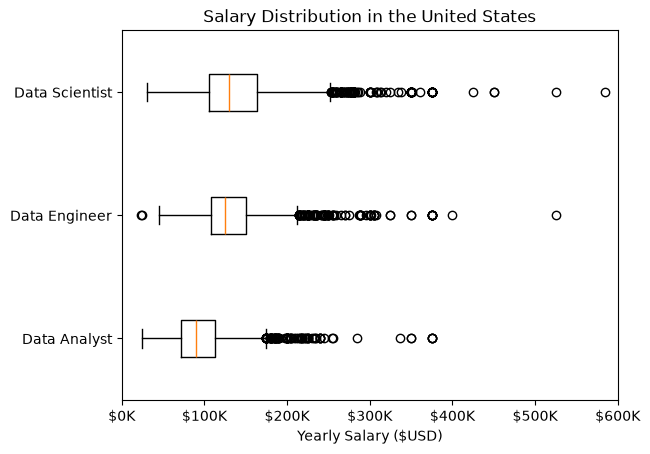

In [41]:
plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.set_xlim(0, 600000)
plt.show()